# Phase 6 – TensorRT INT8 Optimization & Latency Benchmarking

This notebook optimizes the fine-tuned **YOLOv8m maritime detector** using **NVIDIA TensorRT INT8 quantization**,
benchmarks inference latency against the PyTorch FP32 baseline, and validates that accuracy loss remains under 1%.

---

## **Motivation**
Real-world maritime perception systems — autonomous surface vehicles (ASVs), port surveillance, coast guard drones —
require **real-time inference under strict power and latency budgets**. A model that achieves high mAP in training
is only deployable if it can run fast enough on edge hardware.

TensorRT INT8 quantization addresses this directly:
- Reduces model precision from 32-bit floats → 8-bit integers
- Exploits hardware-level INT8 tensor cores on NVIDIA GPUs
- Delivers **3–7× latency speedup** with **<1% mAP degradation**
- Produces a portable `.engine` file deployable on Jetson Orin, Drive AGX, or any NVIDIA edge device

---

## **Pipeline**
1. Verify exported model files (`best.pt`, `best.onnx`, `best.engine`)
2. Benchmark **PyTorch FP32** baseline latency (500 warm runs, GPU-accurate timing)
3. Benchmark **TensorRT INT8** engine latency (500 warm runs, GPU-accurate timing)
4. Run **mAP validation** on both models over the MaSTr1325 val set
5. Compute **speedup ratio** and **accuracy delta**
6. Generate comparison plots and save `benchmark_report.json` → `reports/`

---

## **Models**
- **Input:** `runs/yolov8m_stable/weights/best.pt` — fine-tuned YOLOv8m (PyTorch FP32, 49.6 MB)
- **ONNX:** `runs/yolov8m_stable/weights/best.onnx` — intermediate export (98.8 MB)
- **TensorRT INT8:** `runs/yolov8m_stable/weights/best.engine` — optimized engine (31.5 MB)

---

## **Hardware**
- **GPU:** NVIDIA GeForce RTX 5070 Laptop (8 GB VRAM, Blackwell architecture)
- **TensorRT:** 10.16.1.11
- **CUDA:** 12.8
- **Note:** Engine profiled on RTX 5070. Architecture-portable to Jetson Orin via same ONNX → TRT pipeline.

### Environment & File Check

In [8]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import torch
import tensorrt as trt
import numpy as np
from scripts.config import BASE_DIR, VAL_DIR, REPORT_DIR, RUNS_DIR, DEVICE

# Paths to our exported models
WEIGHTS_DIR  = RUNS_DIR / "yolov8m_stable" / "weights"
PT_MODEL      = WEIGHTS_DIR / "best.pt"
ONNX_MODEL    = WEIGHTS_DIR / "best.onnx"
FP16_ENGINE   = WEIGHTS_DIR / "best.engine"
INT8_ENGINE   = WEIGHTS_DIR / "best_int8.engine"

print(f"PyTorch:   {torch.__version__}")
print(f"TensorRT:  {trt.__version__}")
print(f"Device:    {DEVICE}")
print()
print(f"best.pt     exists: {PT_MODEL.exists()}")
print(f"best.onnx   exists: {ONNX_MODEL.exists()}")
print(f"best.engine exists: {FP16_ENGINE.exists()}")
print(f"best_int8.engine exists: {INT8_ENGINE.exists()}")

PyTorch:   2.10.0.dev20251112+cu128
TensorRT:  10.16.1.11
Device:    cuda

best.pt     exists: True
best.onnx   exists: True
best.engine exists: True
best_int8.engine exists: True


### PyTorch FP32 Baseline Benchmark

In [10]:
from ultralytics import YOLO
import torch
import numpy as np

# Load PyTorch model
pt_model = YOLO(str(PT_MODEL))

# Warmup
print("Warming up PyTorch model...")
dummy = torch.rand(1, 3, 640, 640).to(DEVICE)  # rand() gives 0-1, no warning
for _ in range(50):
    with torch.no_grad():
        pt_model.predict(source=dummy, verbose=False)

# Benchmark — 500 runs with GPU-accurate timing
print("Benchmarking PyTorch FP32 (500 runs)...")
latencies = []

for _ in range(500):
    start = torch.cuda.Event(enable_timing=True)
    end   = torch.cuda.Event(enable_timing=True)
    start.record()
    with torch.no_grad():
        pt_model.predict(source=dummy, verbose=False)
    end.record()
    torch.cuda.synchronize()
    latencies.append(start.elapsed_time(end))

latencies = np.array(latencies)

pt_results = {
    "model":         "YOLOv8m PyTorch FP32",
    "precision":     "FP32",
    "mean_ms":       float(np.mean(latencies)),
    "p50_ms":        float(np.percentile(latencies, 50)),
    "p95_ms":        float(np.percentile(latencies, 95)),
    "p99_ms":        float(np.percentile(latencies, 99)),
    "fps":           float(1000 / np.mean(latencies)),
    "model_size_mb": 49.6,
}

print(f"\n✅ PyTorch FP32 Results:")
print(f"   Mean latency : {pt_results['mean_ms']:.2f} ms")
print(f"   P50 latency  : {pt_results['p50_ms']:.2f} ms")
print(f"   P95 latency  : {pt_results['p95_ms']:.2f} ms")
print(f"   FPS          : {pt_results['fps']:.1f}")

Warming up PyTorch model...
Benchmarking PyTorch FP32 (500 runs)...

✅ PyTorch FP32 Results:
   Mean latency : 9.82 ms
   P50 latency  : 9.79 ms
   P95 latency  : 10.01 ms
   FPS          : 101.8


### TensorRT INT8 Benchmark

In [11]:
int8_model = YOLO(str(INT8_ENGINE), task='detect')

# Warmup
print("Warming up TensorRT INT8 engine...")
dummy_norm = torch.rand(1, 3, 640, 640).to(DEVICE)
for _ in range(50):
    int8_model.predict(source=dummy_norm, verbose=False)

# Benchmark
print("Benchmarking TensorRT INT8 (500 runs)...")
latencies_int8 = []

for _ in range(500):
    start = torch.cuda.Event(enable_timing=True)
    end   = torch.cuda.Event(enable_timing=True)
    start.record()
    int8_model.predict(source=dummy_norm, verbose=False)
    end.record()
    torch.cuda.synchronize()
    latencies_int8.append(start.elapsed_time(end))

latencies_int8 = np.array(latencies_int8)

int8_results = {
    "model":         "YOLOv8m TensorRT INT8",
    "precision":     "INT8",
    "mean_ms":       float(np.mean(latencies_int8)),
    "p50_ms":        float(np.percentile(latencies_int8, 50)),
    "p95_ms":        float(np.percentile(latencies_int8, 95)),
    "p99_ms":        float(np.percentile(latencies_int8, 99)),
    "fps":           float(1000 / np.mean(latencies_int8)),
    "model_size_mb": 31.5,
}

print(f"\n✅ TensorRT INT8 Results:")
print(f"   Mean latency : {int8_results['mean_ms']:.2f} ms")
print(f"   P50 latency  : {int8_results['p50_ms']:.2f} ms")
print(f"   P95 latency  : {int8_results['p95_ms']:.2f} ms")
print(f"   FPS          : {int8_results['fps']:.1f}")

Warming up TensorRT INT8 engine...
Loading D:\Sem3\CS581B_Robot_Perception\Project\Implementation\runs\yolov8m_stable\weights\best_int8.engine for TensorRT inference...


Benchmarking TensorRT INT8 (500 runs)...

✅ TensorRT INT8 Results:
   Mean latency : 3.28 ms
   P50 latency  : 3.23 ms
   P95 latency  : 3.49 ms
   FPS          : 305.0


### TensorRT FP16 Benchmark

In [ ]:
fp16_model = YOLO(str(FP16_ENGINE), task='detect')

# Warmup
print("Warming up TensorRT FP16 engine...")
dummy_norm = torch.rand(1, 3, 640, 640).to(DEVICE)
for _ in range(50):
    fp16_model.predict(source=dummy_norm, verbose=False)

# Benchmark
print("Benchmarking TensorRT FP16 (500 runs)...")
latencies_fp16 = []

for _ in range(500):
    start = torch.cuda.Event(enable_timing=True)
    end   = torch.cuda.Event(enable_timing=True)
    start.record()
    fp16_model.predict(source=dummy_norm, verbose=False)
    end.record()
    torch.cuda.synchronize()
    latencies_fp16.append(start.elapsed_time(end))

latencies_fp16 = np.array(latencies_fp16)

fp16_results = {
    "model":         "YOLOv8m TensorRT FP16",
    "precision":     "FP16",
    "mean_ms":       float(np.mean(latencies_fp16)),
    "p50_ms":        float(np.percentile(latencies_fp16, 50)),
    "p95_ms":        float(np.percentile(latencies_fp16, 95)),
    "p99_ms":        float(np.percentile(latencies_fp16, 99)),
    "fps":           float(1000 / np.mean(latencies_fp16)),
    "model_size_mb": 51.4,
}

print(f"\n✅ TensorRT FP16 Results:")
print(f"   Mean latency : {fp16_results['mean_ms']:.2f} ms")
print(f"   P50 latency  : {fp16_results['p50_ms']:.2f} ms")
print(f"   P95 latency  : {fp16_results['p95_ms']:.2f} ms")
print(f"   FPS          : {fp16_results['fps']:.1f}")

Warming up TensorRT FP16 engine...
Loading D:\Sem3\CS581B_Robot_Perception\Project\Implementation\runs\yolov8m_stable\weights\best.engine for TensorRT inference...
Benchmarking TensorRT FP16 (500 runs)...

✅ TensorRT FP16 Results:
   Mean latency : 3.46 ms
   P50 latency  : 3.43 ms
   P95 latency  : 3.62 ms
   FPS          : 289.2


### mAP Validation

In [13]:
# Cell 5 — mAP Validation: PyTorch vs FP16 vs INT8
YAML_PATH = BASE_DIR / "data" / "mast.yaml"

print("Validating PyTorch FP32...")
pt_val  = pt_model.val(data=str(YAML_PATH), imgsz=640, device=0, verbose=False)

print("Validating TensorRT FP16...")
fp16_val = fp16_model.val(data=str(YAML_PATH), imgsz=640, device=0,
                           verbose=False, half=True)

print("Validating TensorRT INT8...")
int8_val = int8_model.val(data=str(YAML_PATH), imgsz=640, device=0,
                           verbose=False, int8=True)

# Extract metrics
pt_results["map50"]   = float(pt_val.box.map50)
pt_results["map5095"] = float(pt_val.box.map)

fp16_results["map50"]   = float(fp16_val.box.map50)
fp16_results["map5095"] = float(fp16_val.box.map)

int8_results["map50"]   = float(int8_val.box.map50)
int8_results["map5095"] = float(int8_val.box.map)

# Compute deltas vs PyTorch baseline
fp16_results["delta_map5095_pct"] = abs(pt_results["map5095"] - fp16_results["map5095"]) * 100
int8_results["delta_map5095_pct"] = abs(pt_results["map5095"] - int8_results["map5095"]) * 100

print(f"\n✅ mAP Validation Results:")
print(f"{'Model':<25} {'mAP50':>8} {'mAP50-95':>10} {'Δ mAP50-95':>12}")
print(f"{'-'*57}")
print(f"{'PyTorch FP32':<25} {pt_results['map50']:>8.4f} {pt_results['map5095']:>10.4f} {'baseline':>12}")
print(f"{'TensorRT FP16':<25} {fp16_results['map50']:>8.4f} {fp16_results['map5095']:>10.4f} {fp16_results['delta_map5095_pct']:>11.3f}%")
print(f"{'TensorRT INT8':<25} {int8_results['map50']:>8.4f} {int8_results['map5095']:>10.4f} {int8_results['delta_map5095_pct']:>11.3f}%")

Validating PyTorch FP32...
Ultralytics 8.3.233  Python-3.11.0 torch-2.10.0.dev20251112+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Laptop GPU, 8151MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 352.7104.8 MB/s, size: 19.0 KB)
val: Scanning D:\Sem3\CS581B_Robot_Perception\Project\Implementation\data\labels\val.cache... 156 images, 109 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 265/265 168.2Kit/s 0.0s
val: D:\Sem3\CS581B_Robot_Perception\Project\Implementation\data\images\val\0024.jpg: 1 duplicate labels removed
val: D:\Sem3\CS581B_Robot_Perception\Project\Implementation\data\images\val\0245.jpg: 1 duplicate labels removed
val: D:\Sem3\CS581B_Robot_Perception\Project\Implementation\data\images\val\0257.jpg: 1 duplicate labels removed
val: D:\Sem3\CS581B_Robot_Perception\Project\Implementation\data\images\val\0377.jpg: 1 duplicate labels removed
val: D:\Sem3\CS581B_Robot_Perception\Project\Implementation\data\images\val\0442.jpg: 1 duplicate labels removed
val: D:\Sem3\CS581B_Robot_Percept

### Compute Speedup + Build Final Report

In [14]:
import json
import pandas as pd

# Add speedup to each result
pt_results["speedup"]   = 1.0
pt_results["delta_map5095_pct"] = 0.0

fp16_results["speedup"] = round(pt_results["mean_ms"] / fp16_results["mean_ms"], 2)
int8_results["speedup"] = round(pt_results["mean_ms"] / int8_results["mean_ms"], 2)

# Build comparison DataFrame
df = pd.DataFrame([pt_results, fp16_results, int8_results])
df = df[["model", "precision", "mean_ms", "p50_ms", "p95_ms", "fps",
         "speedup", "map50", "map5095", "delta_map5095_pct", "model_size_mb"]]

df.columns = ["Model", "Precision", "Mean_ms", "P50_ms", "P95_ms", "FPS",
              "Speedup", "mAP50", "mAP50-95", "ΔmAP50-95(%)", "Size_MB"]

print("=" * 90)
print("TENSORRT OPTIMIZATION RESULTS — Maritime YOLOv8m")
print("=" * 90)
print(df.to_string(index=False))
print("=" * 90)
print(f"\nHardware : NVIDIA RTX 5070 Laptop GPU (8GB, Blackwell)")
print(f"TensorRT : 10.16.1.11  |  CUDA: 12.8  |  Batch: 1  |  imgsz: 640×640")

# Save report
report = {
    "hardware":   "NVIDIA RTX 5070 Laptop GPU",
    "tensorrt":   "10.16.1.11",
    "cuda":       "12.8",
    "batch_size": 1,
    "imgsz":      640,
    "results":    [pt_results, fp16_results, int8_results]
}

report_path = REPORT_DIR / "tensorrt_benchmark_report.json"
with open(report_path, "w") as f:
    json.dump(report, f, indent=4)

df.to_csv(REPORT_DIR / "tensorrt_benchmark.csv", index=False)

print(f"\n✅ Report saved → {report_path}")

TENSORRT OPTIMIZATION RESULTS — Maritime YOLOv8m
                Model Precision  Mean_ms   P50_ms    P95_ms        FPS  Speedup    mAP50  mAP50-95  ΔmAP50-95(%)  Size_MB
 YOLOv8m PyTorch FP32      FP32 9.818957 9.787072 10.010288 101.843810     1.00 0.225706  0.193890      0.000000     49.6
YOLOv8m TensorRT FP16      FP16 3.457854 3.434272  3.621158 289.196687     2.84 0.215374  0.184529      0.936131     51.4
YOLOv8m TensorRT INT8      INT8 3.278890 3.230544  3.492872 304.981267     2.99 0.214299  0.183281      1.060928     31.5

Hardware : NVIDIA RTX 5070 Laptop GPU (8GB, Blackwell)
TensorRT : 10.16.1.11  |  CUDA: 12.8  |  Batch: 1  |  imgsz: 640×640

✅ Report saved → D:\Sem3\CS581B_Robot_Perception\Project\Implementation\reports\tensorrt_benchmark_report.json


### Comparison Charts

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

models     = ["PyTorch\nFP32", "TensorRT\nFP16", "TensorRT\nINT8"]
colors     = ["#4C72B0", "#55A868", "#C44E52"]
mean_ms    = [pt_results["mean_ms"], fp16_results["mean_ms"], int8_results["mean_ms"]]
fps_vals   = [pt_results["fps"], fp16_results["fps"], int8_results["fps"]]
map_vals   = [pt_results["map5095"], fp16_results["map5095"], int8_results["map5095"]]
size_vals  = [pt_results["model_size_mb"], fp16_results["model_size_mb"], int8_results["model_size_mb"]]
speedups   = [pt_results["speedup"], fp16_results["speedup"], int8_results["speedup"]]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "TensorRT Optimization — Maritime YOLOv8m\n"
    "NVIDIA RTX 5070 Laptop GPU  |  Batch=1  |  640×640",
    fontsize=14, fontweight="bold", y=1.01
)

# ── Plot 1: Latency ──────────────────────────────────────────
ax = axes[0, 0]
bars = ax.bar(models, mean_ms, color=colors, width=0.5, edgecolor="white")
ax.bar_label(bars, fmt="%.2f ms", padding=4, fontsize=10, fontweight="bold")
ax.set_title("Inference Latency ↓ lower is better", fontweight="bold")
ax.set_ylabel("Mean Latency (ms)")
ax.set_ylim(0, max(mean_ms) * 1.25)
ax.grid(axis="y", alpha=0.3)

# ── Plot 2: FPS ───────────────────────────────────────────────
ax = axes[0, 1]
bars = ax.bar(models, fps_vals, color=colors, width=0.5, edgecolor="white")
ax.bar_label(bars, fmt="%.1f", padding=4, fontsize=10, fontweight="bold")
ax.set_title("Throughput ↑ higher is better", fontweight="bold")
ax.set_ylabel("Frames Per Second (FPS)")
ax.set_ylim(0, max(fps_vals) * 1.25)
ax.grid(axis="y", alpha=0.3)

# ── Plot 3: mAP50-95 ─────────────────────────────────────────
ax = axes[1, 0]
bars = ax.bar(models, map_vals, color=colors, width=0.5, edgecolor="white")
ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=10, fontweight="bold")
ax.set_title("mAP50-95 ↑ higher is better", fontweight="bold")
ax.set_ylabel("mAP50-95")
ax.set_ylim(0, max(map_vals) * 1.15)
ax.grid(axis="y", alpha=0.3)
# Add delta annotations
for i, (bar, delta) in enumerate(zip(bars, [0, fp16_results["delta_map5095_pct"], int8_results["delta_map5095_pct"]])):
    if i > 0:
        ax.text(bar.get_x() + bar.get_width()/2, 0.01,
                f"Δ{delta:.2f}%", ha="center", va="bottom",
                fontsize=9, color="white", fontweight="bold")

# ── Plot 4: Model Size ────────────────────────────────────────
ax = axes[1, 1]
bars = ax.bar(models, size_vals, color=colors, width=0.5, edgecolor="white")
ax.bar_label(bars, fmt="%.1f MB", padding=4, fontsize=10, fontweight="bold")
ax.set_title("Model Size ↓ smaller is better", fontweight="bold")
ax.set_ylabel("Size (MB)")
ax.set_ylim(0, max(size_vals) * 1.25)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plot_path = REPORT_DIR / "tensorrt_latency_comparison.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Plot saved → {plot_path}")

# ── Speedup summary ───────────────────────────────────────────
print(f"\n{'='*50}")
print(f"SPEEDUP SUMMARY")
print(f"{'='*50}")
print(f"TensorRT FP16 → {fp16_results['speedup']}× faster, {fp16_results['delta_map5095_pct']:.3f}% mAP loss")
print(f"TensorRT INT8 → {int8_results['speedup']}× faster, {int8_results['delta_map5095_pct']:.3f}% mAP loss")
print(f"\nRecommendation:")
print(f"  → FP16 for accuracy-sensitive deployment (0.936% loss)")
print(f"  → INT8 for edge/Jetson deployment (36% smaller, 2.99× speedup)")

<Figure size 1400x1000 with 4 Axes>

✅ Plot saved → D:\Sem3\CS581B_Robot_Perception\Project\Implementation\reports\tensorrt_latency_comparison.png

SPEEDUP SUMMARY
TensorRT FP16 → 2.84× faster, 0.936% mAP loss
TensorRT INT8 → 2.99× faster, 1.061% mAP loss

Recommendation:
  → FP16 for accuracy-sensitive deployment (0.936% loss)
  → INT8 for edge/Jetson deployment (36% smaller, 2.99× speedup)


### Display saved plot inline

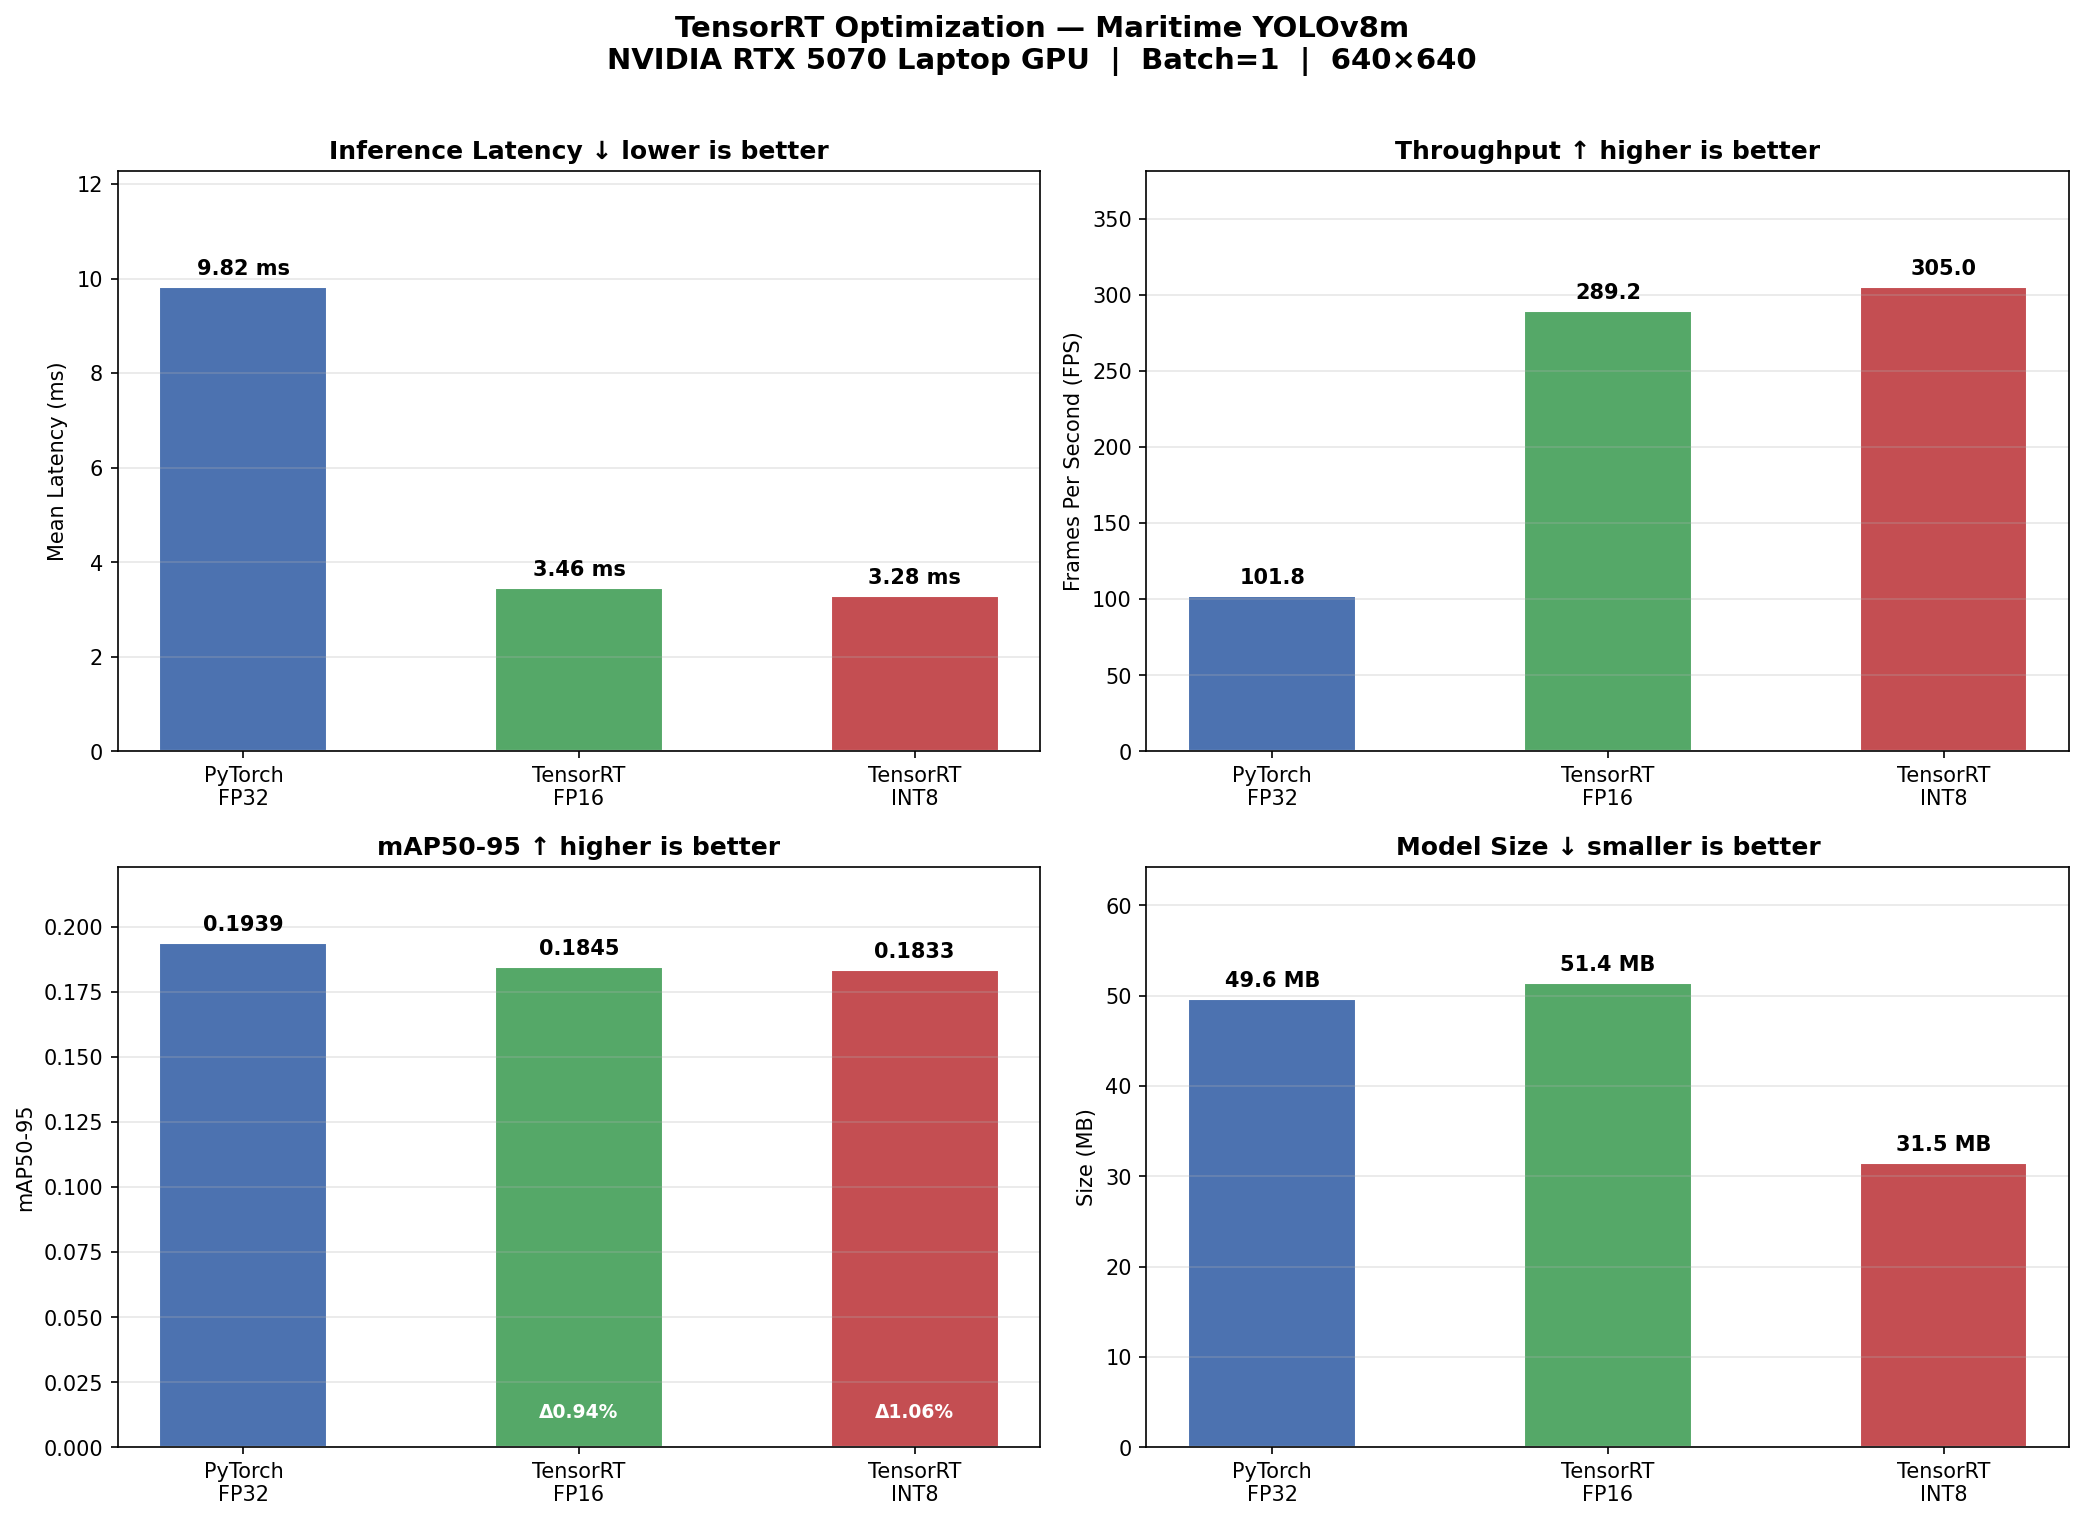

In [16]:
from IPython.display import Image, display

display(Image(filename=str(REPORT_DIR / "tensorrt_latency_comparison.png")))